### Data profiling,Cleaning and Eda For Sierraleone-Bumbuna

In [47]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
%matplotlib inline

In [48]:
#load the dataset
sierra_data = pd.read_csv('../data/sierraleone-bumbuna.csv')
# dispaly the first few rows of the dataset
sierra_data.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [49]:
# check the data types of each column
sierra_data.dtypes

Timestamp         object
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

In [50]:
#  descrive the dataset to get summery statictics
sierra_data.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN


In [51]:
# check for missing values
missing_value=sierra_data.isnull().sum()
total_len=len(sierra_data)
missing_percentage=(missing_value/total_len)* 100
missing_percentage

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [52]:
# dispaly the column with missing values percentage greater than 5
for col,percent in missing_percentage.items():
    if percent > 5:
        print(f"{col}: {percent}%")

Comments: 100.0%


In [53]:
# let us have copy of thr data for cleaning
sierra_cp=sierra_data.copy()
sierra_cp.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [54]:
# drop columns with more than 5%  missing values
cols_to_drop=[col for col,percent in missing_percentage.items() if percent >5]
cols_to_drop
sierra_cp.drop(columns=cols_to_drop, inplace=True)

In [55]:
# important numerical columns
num_cols=['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb']

In [56]:
# check for outliers using z-score method in numerical columns
outlier_flag = np.abs(zscore(sierra_cp[num_cols])) 
outliers = (outlier_flag > 3).any(axis=1)
sierra_cp['Outlires'] = outliers
sierra_cp['Outlires'].value_counts()





Outlires
False    513634
True      11966
Name: count, dtype: int64

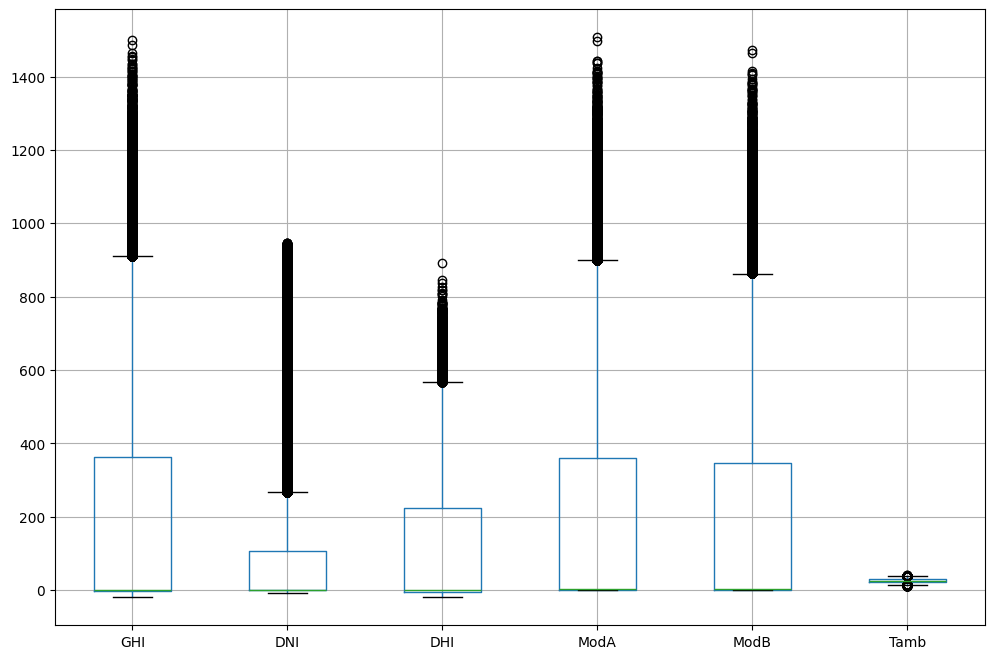

In [57]:
# plot boxplot for numeric cols
sierra_cp.boxplot(num_cols,figsize=(12,8));

In [58]:
# export cleaned data
sierra_cp.to_csv('../data/sierraleone-bumbuna-cleaned.csv',index=False)

### TIme Series Analysis

In [59]:
# timestamp column 
sierra_cp.Timestamp

0         2021-10-30 00:01
1         2021-10-30 00:02
2         2021-10-30 00:03
3         2021-10-30 00:04
4         2021-10-30 00:05
                ...       
525595    2022-10-29 23:56
525596    2022-10-29 23:57
525597    2022-10-29 23:58
525598    2022-10-29 23:59
525599    2022-10-30 00:00
Name: Timestamp, Length: 525600, dtype: object

In [60]:
# convert timestamp column to datetime
sierra_cp["Timestamp"]=pd.to_datetime(sierra_cp.Timestamp)
sierra_cp.set_index("Timestamp",inplace=True)

### Timestamp Plots

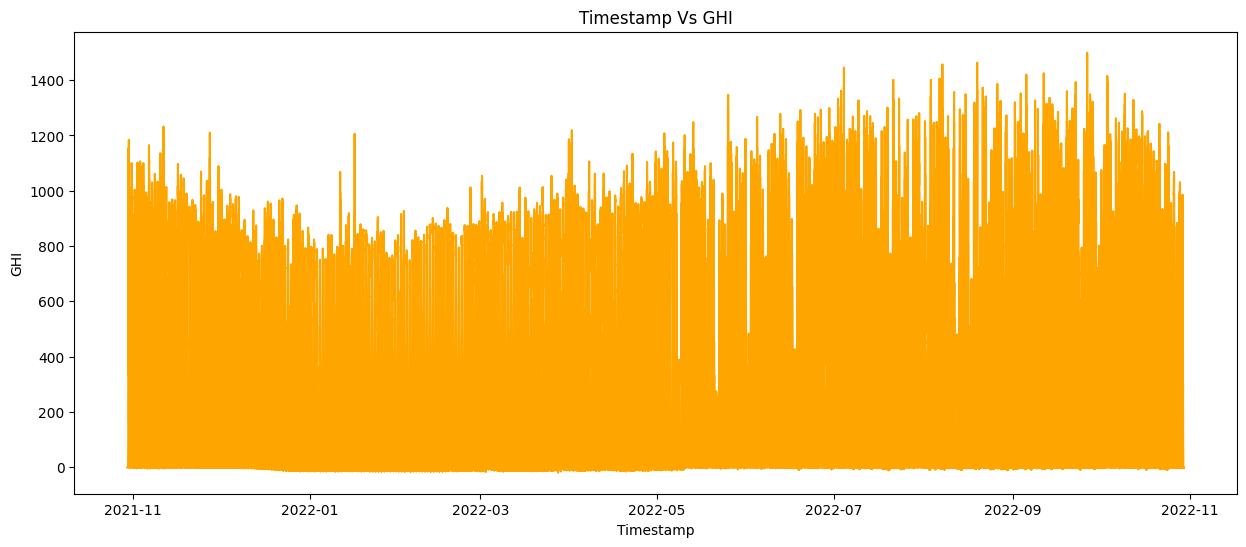

In [61]:
# Timestamp Vs GHI plot
plt.figure(figsize=(15,6))
plt.plot(sierra_cp.index,sierra_cp["GHI"],color='orange')
plt.title('Timestamp Vs GHI')
plt.xlabel('Timestamp')
plt.ylabel('GHI')
plt.show()


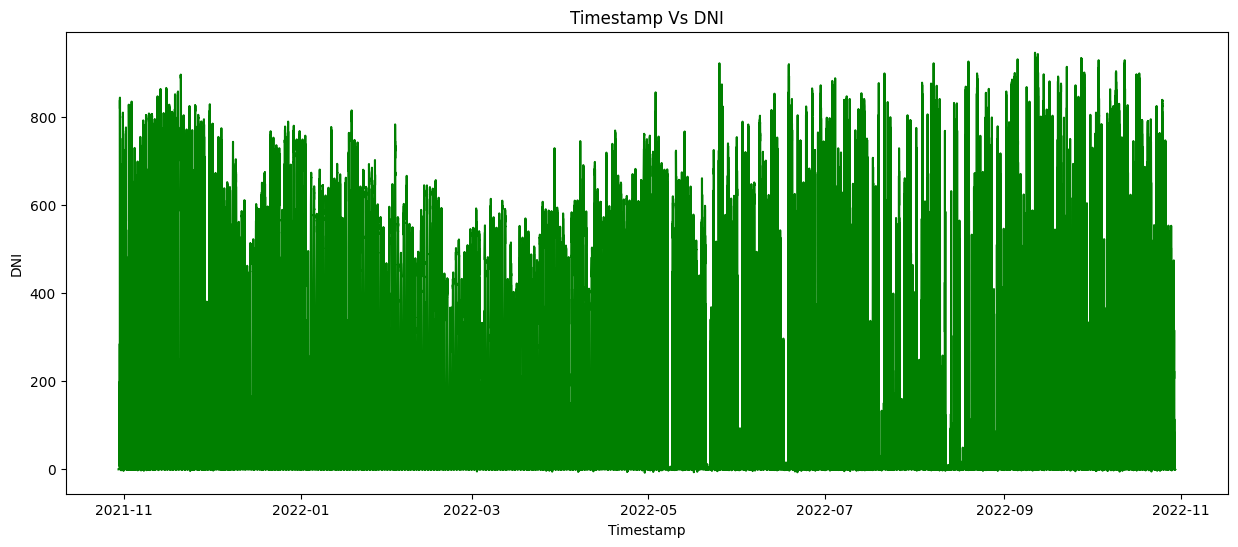

In [62]:
# Timestamp vs DNI plot
plt.figure(figsize=(15,6))
plt.plot(sierra_cp.index,sierra_cp["DNI"],color='green')
plt.title('Timestamp Vs DNI')
plt.xlabel('Timestamp')
plt.ylabel('DNI')
plt.show()

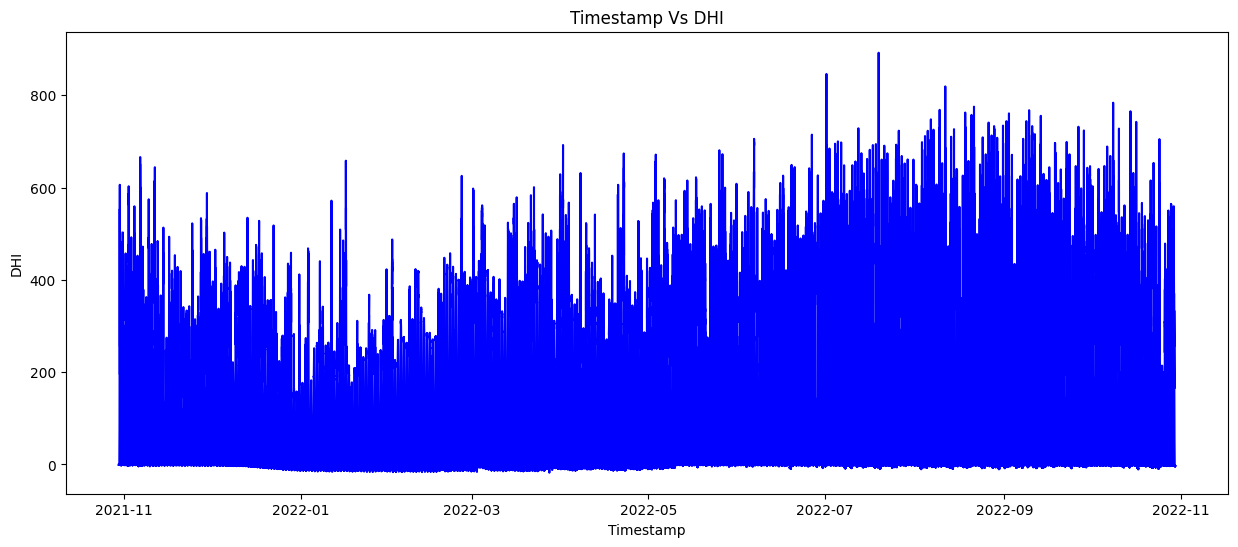

In [63]:
# Timestamp vs DHI plot
plt.figure(figsize=(15,6))
plt.plot(sierra_cp.index,sierra_cp["DHI"],color='blue')
plt.title('Timestamp Vs DHI')
plt.xlabel('Timestamp')
plt.ylabel('DHI')
plt.show()

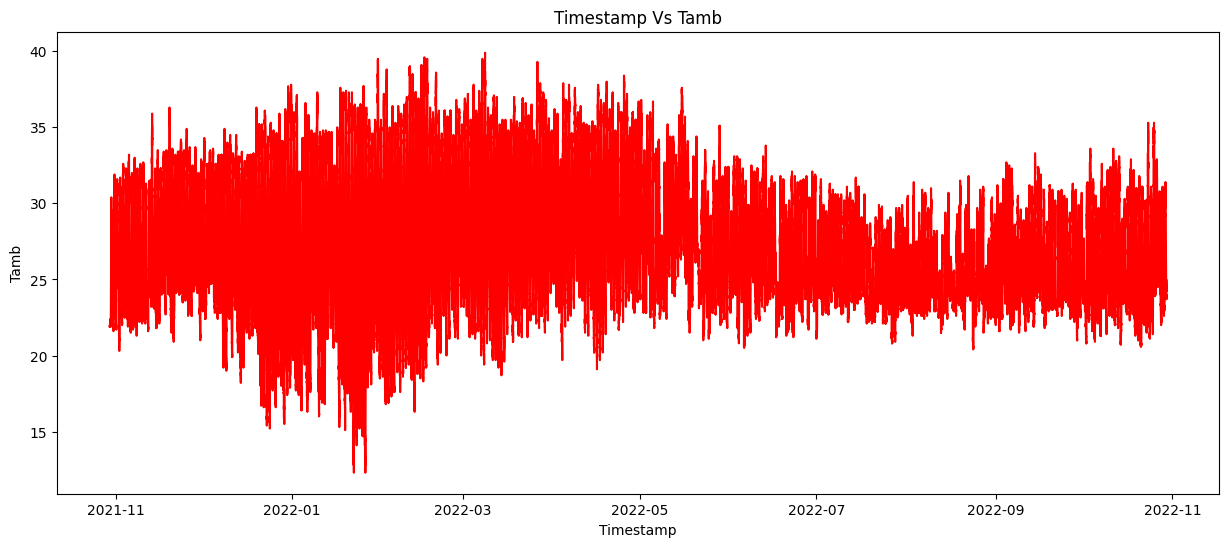

In [64]:
# Timestamp vs Tamb plot
plt.figure(figsize=(15,6))
plt.plot(sierra_cp.index,sierra_cp["Tamb"],color='red')
plt.title('Timestamp Vs Tamb')
plt.xlabel('Timestamp')
plt.ylabel('Tamb')
plt.show()

In [65]:
# observe  patterns in months
sierra_cp['Month']=sierra_cp.index.month # extract month from timestamp
# compute monthly average for numeric columns
monthly_avg=sierra_cp.groupby('Month')[num_cols].mean()
monthly_avg

,GHI,DNI,DHI,ModA,ModB,Tamb
Month,,,,,,
1,196.847731,168.745343,78.310069,228.188481,213.874238,25.329689
2,219.716979,147.174861,107.792954,241.637899,231.474640,27.185801
3,231.273602,129.395663,126.952959,240.931172,224.868873,28.359635
4,236.642894,144.402826,117.430572,233.471414,224.709088,28.747725
5,203.376830,98.968831,123.982350,188.229315,182.365466,27.282619
6,200.210752,98.433542,121.722294,181.543352,172.759148,25.957787
7,169.493488,54.277652,127.461676,157.837845,152.314527,25.114666
8,154.948546,40.761927,122.433116,150.776828,146.646884,24.728138
9,193.052606,79.690856,130.299032,189.926366,185.404900,25.398345


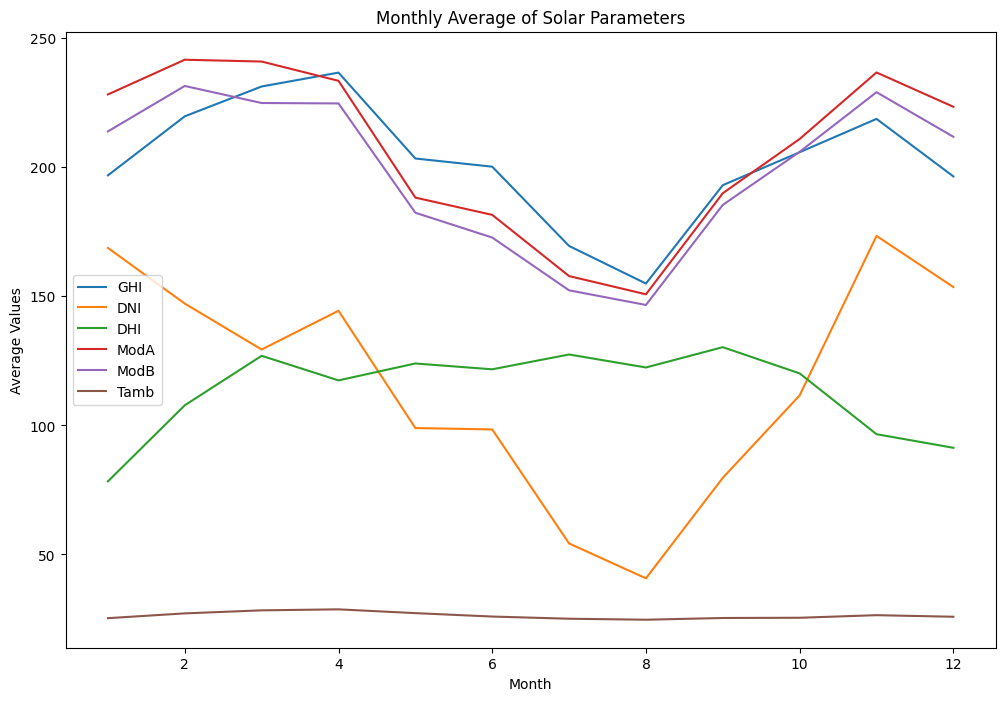

In [66]:
# show monthly pattens plots
monthly_avg.plot(figsize=(12,8))
plt.title('Monthly Average of Solar Parameters')
plt.xlabel('Month')
plt.ylabel('Average Values')
plt.show()

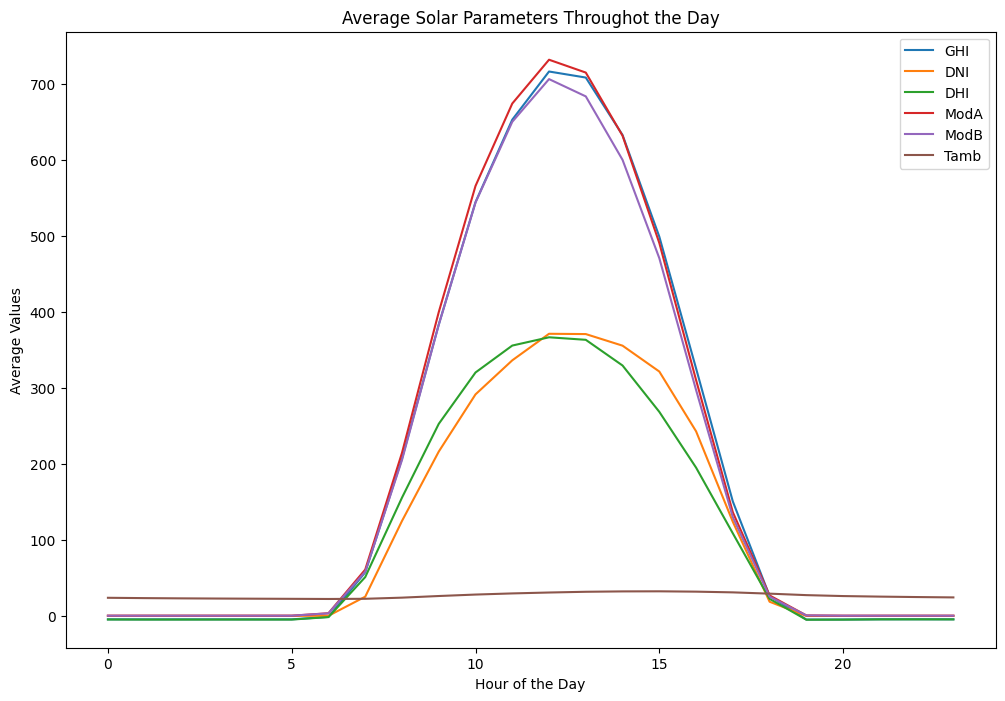

In [67]:
# Trends throughout the day
sierra_cp['Hour']=sierra_cp.index.hour # extraxt hour from timestamp
daily_avg=sierra_cp.groupby('Hour')[num_cols].mean()
daily_avg.plot(figsize=(12,8))
plt.title('Average Solar Parameters Throughot the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Values')
plt.show()

In [68]:
# Detect anomalies in GHI using rolling mean and std deviation
ghi_mean,ghi_std=sierra_cp['GHI'].mean(),sierra_cp['GHI'].std()
# detect anomalies
sierra_cp['GHI_Anomaly']=((sierra_cp['GHI']> (ghi_mean + 3*ghi_std)) | (sierra_cp['GHI']< (ghi_mean - 3*ghi_std)))
sierra_cp['GHI_Anomaly'].value_counts()

GHI_Anomaly
False    523123
True       2477
Name: count, dtype: int64

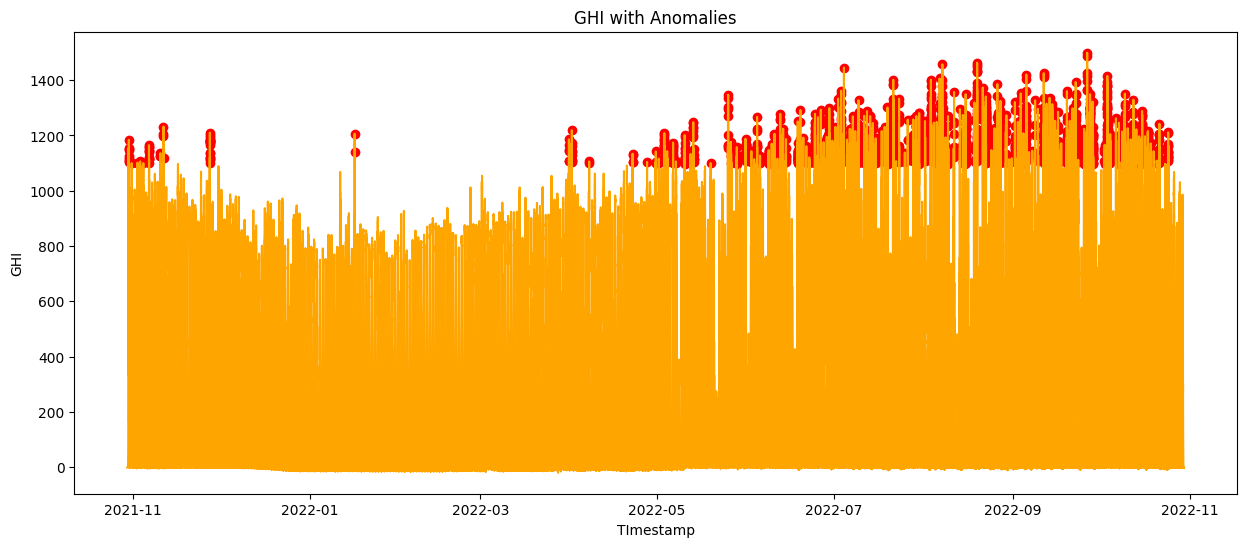

In [69]:
# plot anomalies
plt.figure(figsize=(15,6))
plt.plot(sierra_cp.index,sierra_cp["GHI"],label='GHI',color='orange')
plt.scatter(
    sierra_cp[sierra_cp['GHI_Anomaly']].index, 
    sierra_cp[sierra_cp['GHI_Anomaly']]['GHI'],
    color='red',label='Anomalies')
plt.title('GHI with Anomalies')
plt.xlabel('TImestamp')
plt.ylabel('GHI')
plt.show()

### Cleaning Impact

In [70]:
sierra_cp.ModA.value_counts()

ModA
0.0       246580
0.1         2810
0.2         1335
0.3          965
0.4          780
           ...  
1322.0         1
1312.0         1
1258.0         1
1349.0         1
1399.0         1
Name: count, Length: 10188, dtype: int64

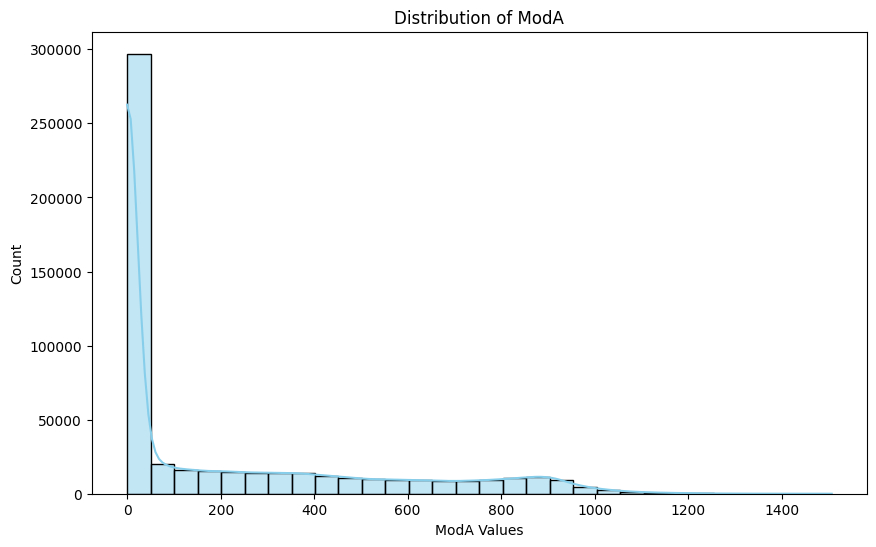

In [71]:
#graph to show distribution of ModA
plt.figure(figsize=(10,6))
sns.histplot(sierra_cp['ModA'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of ModA')
plt.xlabel('ModA Values')
plt.show();

In [72]:
# compute mean and std of ModA
moda_mean=sierra_cp['ModA'].mean()
moda_std=sierra_cp['ModA'].std()
#Flag to identify outliers in ModA
sierra_cp['Cleaning'] = 'Pre'  # default value
sierra_cp.loc[(sierra_cp['ModA']> moda_mean + 3*moda_std) | (sierra_cp['ModA']< moda_mean -3*moda_std), 'Cleaning']= 'Post'
sierra_cp.loc[sierra_cp['ModA'] == 0, 'Cleaning'] = 'Post'
# clean ModA 
upper=moda_mean + 3*moda_std
lower=moda_mean - 3*moda_std
sierra_cp['ModA_clean']=sierra_cp['ModA'].clip(lower,upper)
# group by cleaning status and get average ModA values
avg_moda=sierra_cp.groupby('Cleaning')[['ModA','ModA_clean']].mean()
print(avg_moda)

                ModA  ModA_clean
Cleaning                        
Post        7.622241    7.169565
Pre       384.692637  384.692637


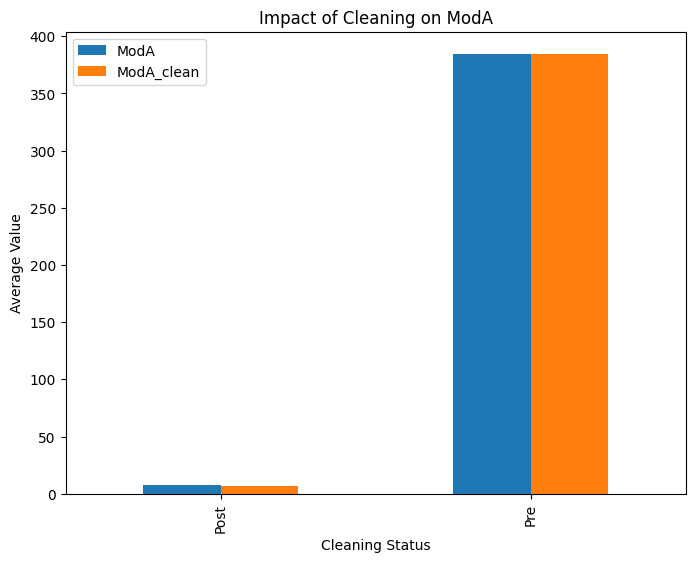

In [73]:
avg_moda.plot(kind='bar', figsize=(8,6)) # plot to show impact of cleaning on ModA
plt.title('Impact of Cleaning on ModA')
plt.ylabel('Average Value')
plt.xlabel('Cleaning Status')
plt.show()

In [74]:
sierra_cp.ModB.describe()

count    525600.000000
mean        198.114691
std         288.889073
min           0.000000
25%           0.000000
50%           3.400000
75%         345.400000
max        1473.000000
Name: ModB, dtype: float64

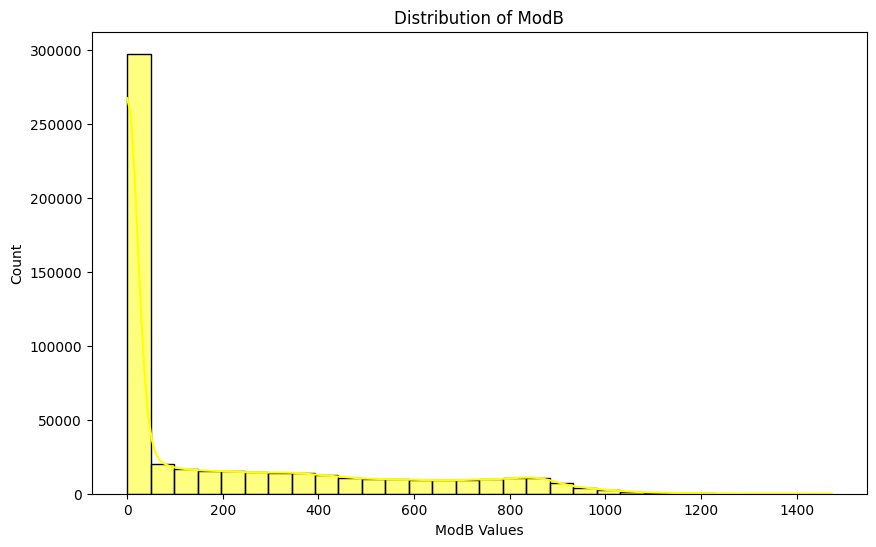

In [75]:
#graph to show distribution of ModA
plt.figure(figsize=(10,6))
sns.histplot(sierra_cp['ModB'], bins=30, kde=True, color='yellow')
plt.title('Distribution of ModB')
plt.xlabel('ModB Values')
plt.show();

In [76]:
# compute mean and std of ModB
modb_mean=sierra_cp['ModA'].mean()
modb_std=sierra_cp['ModA'].std()
#Flag to identify outliers in ModB
sierra_cp['Cleaning'] = 'Pre'  # default value
sierra_cp.loc[(sierra_cp['ModB']> moda_mean + 3*moda_std) | (sierra_cp['ModB']< moda_mean -3*moda_std), 'Cleaning']= 'Post'
sierra_cp.loc[sierra_cp['ModB'] == 0, 'Cleaning'] = 'Post'
# clean ModB
upper=modb_mean + 3*modb_std
lower=modb_mean - 3*modb_std
sierra_cp['ModB_clean']=sierra_cp['ModB'].clip(lower,upper)
# group by cleaning status and get average ModA values
avg_modb=sierra_cp.groupby('Cleaning')[['ModB','ModB_clean']].mean()
print(avg_modb)

                ModB  ModB_clean
Cleaning                        
Post        5.382266    5.079908
Pre       370.396329  370.396329


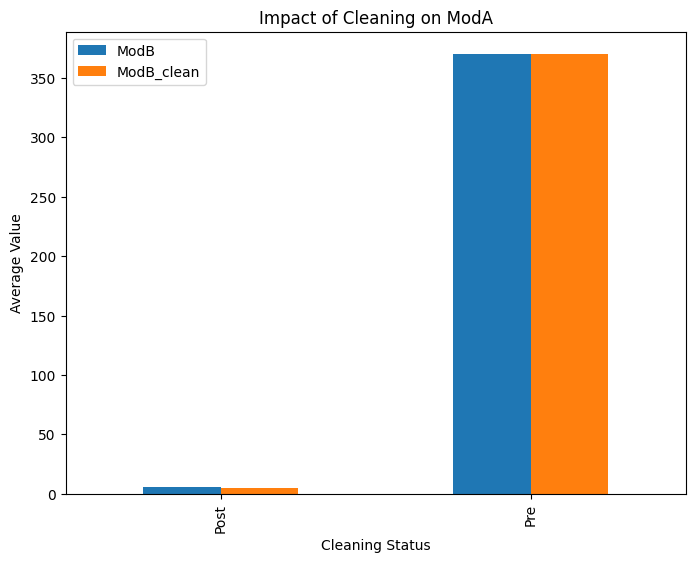

In [77]:
avg_modb.plot(kind='bar', figsize=(8,6)) # plot to show impact of cleaning on ModA
plt.title('Impact of Cleaning on ModA')
plt.ylabel('Average Value')
plt.xlabel('Cleaning Status')
plt.show()

### Correlation & Relationship Analysis

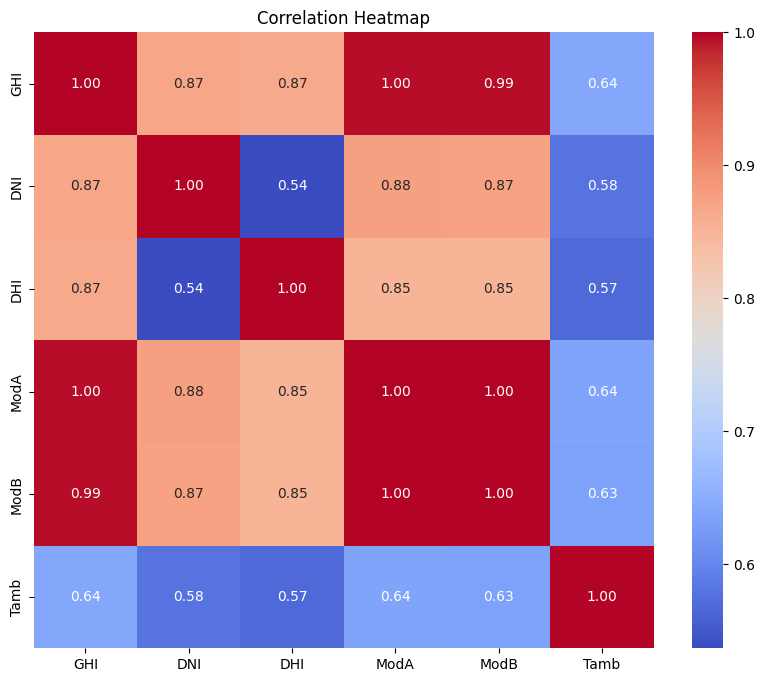

In [78]:
# draw correlation heatmap for numerical columns
plt.figure(figsize=(10,8))
corr_matrix=sierra_cp[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

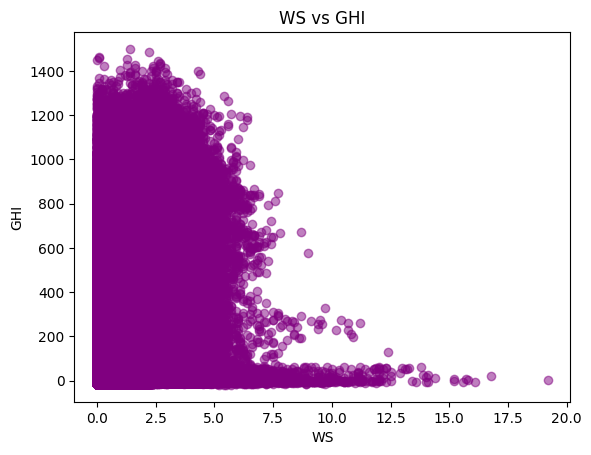

In [79]:
# scatter plot WS vs GHI
plt.scatter(sierra_cp['WS'], sierra_cp['GHI'], alpha=0.5, color='purple')
plt.title('WS vs GHI')
plt.xlabel('WS')
plt.ylabel('GHI')
plt.show()

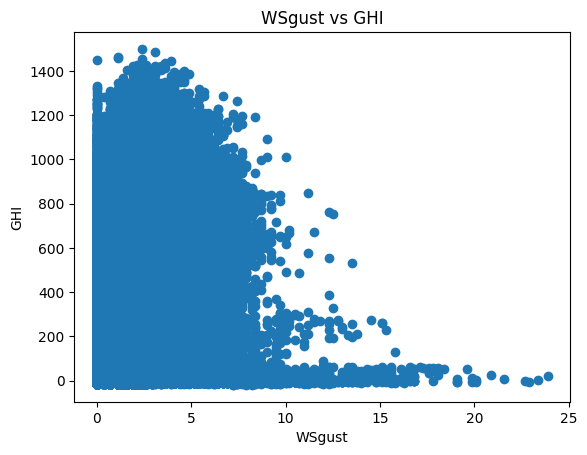

In [80]:
# scatter plot berween WSgust vs GHI
plt.scatter(sierra_cp['WSgust'], sierra_cp['GHI'])
plt.title('WSgust vs GHI')
plt.xlabel('WSgust')
plt.ylabel('GHI')
plt.show()

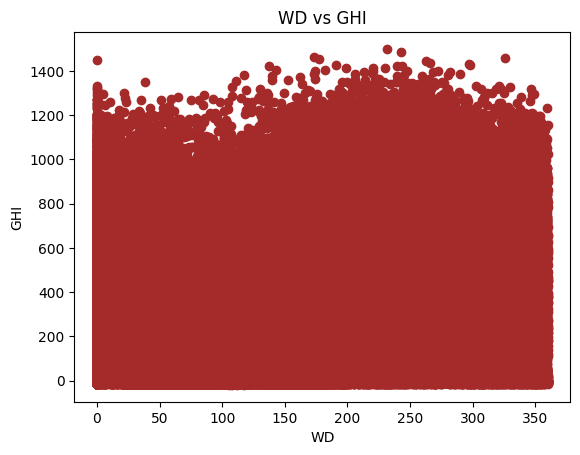

In [81]:
# scatter plot between WD and GHI
plt.scatter(sierra_cp['WD'], sierra_cp['GHI'], color='brown')
plt.title('WD vs GHI')
plt.xlabel('WD')
plt.ylabel('GHI')
plt.show()

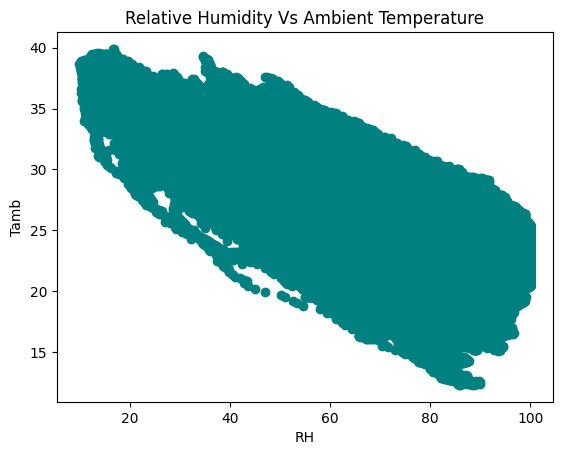

In [82]:
# Scatter plots RH vs Tamb
plt.scatter(sierra_cp['RH'], sierra_cp['Tamb'], color='teal')
plt.title('Relative Humidity Vs Ambient Temperature')
plt.xlabel('RH')
plt.ylabel('Tamb')
plt.show()

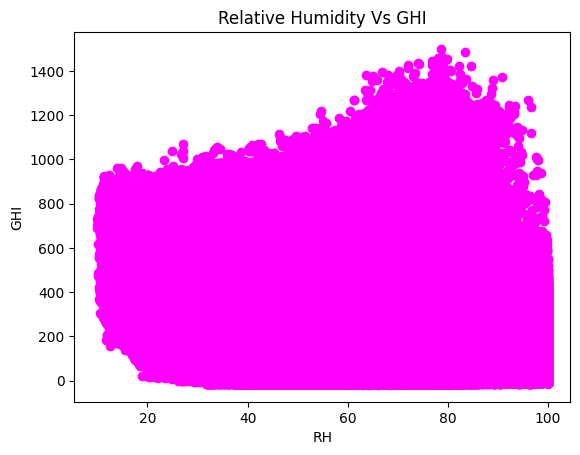

In [83]:
# Scatter RH vs GHI
plt.scatter(sierra_cp['RH'], sierra_cp['GHI'], color='magenta')
plt.title('Relative Humidity Vs GHI')
plt.xlabel('RH')
plt.ylabel('GHI')
plt.show()

### Wind and Distribution analysis

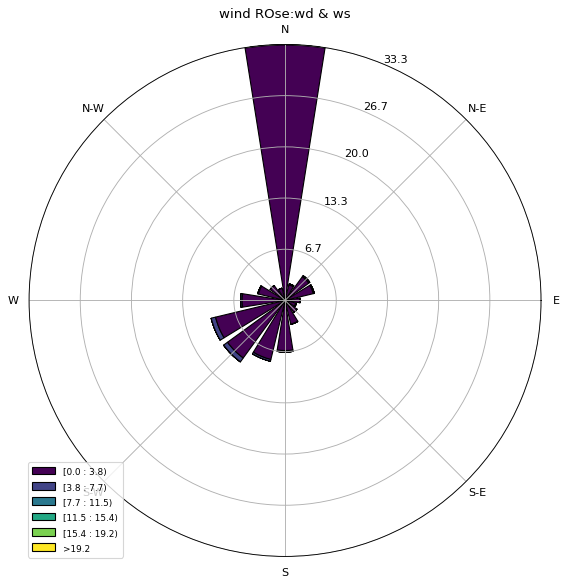

In [84]:
from windrose import WindroseAxes
ax=WindroseAxes.from_ax()
ax.bar(sierra_cp['WD'], sierra_cp['WS'],normed=True, opening=0.8, edgecolor='black')
ax.set_title('wind ROse:wd & ws')
ax.set_legend()
plt.show()

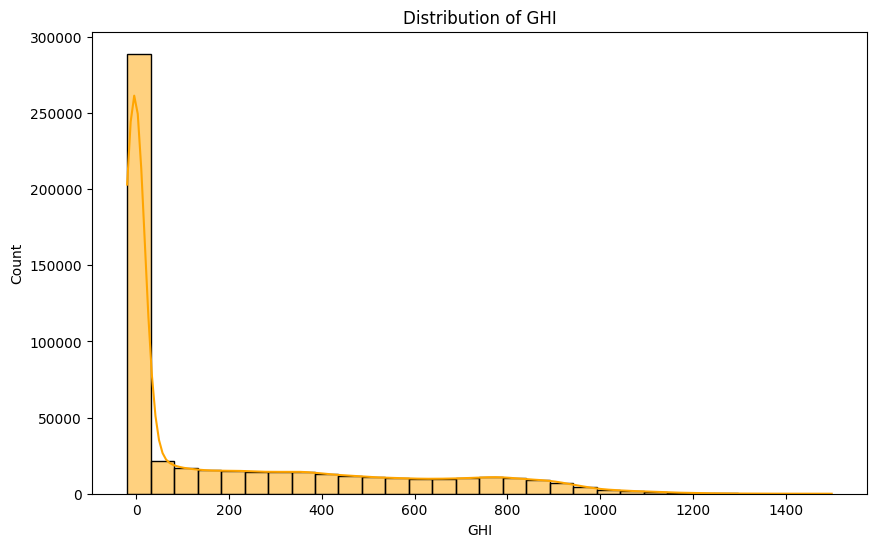

In [85]:
# histogram for GHI
plt.figure(figsize=(10,6))
sns.histplot(sierra_cp['GHI'], bins=30, kde=True, color='orange')
plt.title('Distribution of GHI')
plt.xlabel('GHI')
plt.show();

### Temperature Analysis

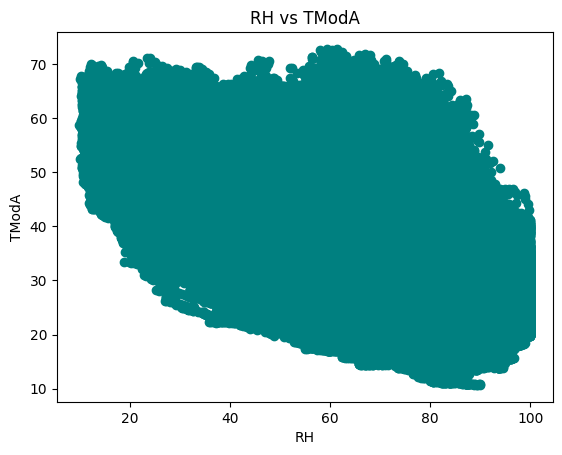

In [86]:
# analyze how RH affects temperature readings
plt.scatter(sierra_cp['RH'], sierra_cp['TModA'], color='teal')
plt.title('RH vs TModA')
plt.xlabel('RH')
plt.ylabel('TModA')
plt.show()

### Bubble Chart

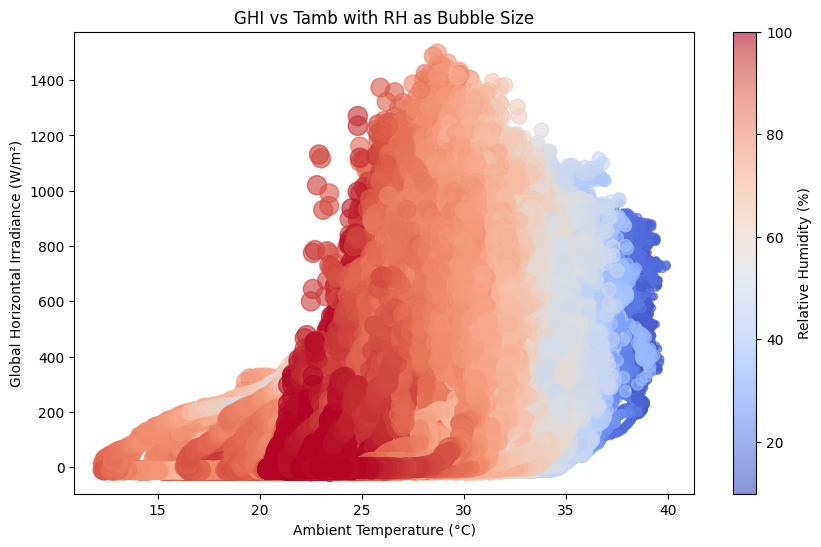

In [87]:
# Using RH as bubble size
plt.figure(figsize=(10,6))
plt.scatter(
    sierra_cp['Tamb'], 
    sierra_cp['GHI'], 
    s=sierra_cp['RH']*2,  # scale bubble size
    alpha=0.6,
    c=sierra_cp['RH'],    # optional: color by RH
    cmap='coolwarm'
)
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.title('GHI vs Tamb with RH as Bubble Size')
plt.colorbar(label='Relative Humidity (%)')
plt.show()